# Trabalho/Atividade 5 em grupo de Regressão

## Integrantes do Grupo:
- Matheus Brito
- Marcella Cobra
- Marcelo Huang

---

Enunciado: "*Encontre um conjunto de dados com, no minimo, 8 covariaveis. Ajuste um modelo de regressão nos seus dados. Use todas as etapas de análise. Escreva os resultados em um Relatorio em PDF. Prepare uma apresentação do seu Relatorio.*"

---

## Conjunto de dados escolhido: 

Resistência à compressão do Concreto  vs. Idade + Componentes (disponível em [UC Irvine: Concrete Compressive Strength](https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength))

## Etapa 0:  Contextualizando

Nesta atividade, será realizada uma análise de um conjunto de dados dito na sala de aula, usando um modelo de regressão linear $Y = X\beta + \varepsilon$.


A partir desses dados, serão conduzidos: Diagnóstico/Análise de resíduos; Detecção de outliers e pontos influentes; Testes estatísticas; e validação do modelo.

Estamos interessados em como os componentes e a idade impacta na resistência à compressão do concreto

O conjunto de dados original é composto por 8 covariáveis e 1 variável resposta:

* $X_1$: Cimento (quantitativa - kg/$m^3$)
* $X_2$: Escória (quantitativa - kg/$m^3$)
* $X_3$: Cinza Volante (quantitativa - kg/$m^3$)
* $X_4$: Água (quantitativa - kg/$m^3$)
* $X_5$: Superplastificante (quantitativa - kg/$m^3$)
* $X_6$: Agregado Graudo (quantitativa - kg/$m^3$)
* $X_7$: Agregado Miudo (quantitativa - kg/$m^3$)
* $X_8$: Idade = o tempo decorrido desde o momento em que a água entra em contato com o cimento (quantitativa - dia)
* $Y$: Resistência a compressão (quantitativa - MPa)


---

Para validação do modelo, o conjunto de dados (total de 1030 observações) foi dividido aleatóriamente com semente 42 para reprodutividade em duas partes: teste (309 observações), treino (721 observações)


*Nessa atividade, as análises serão realizadas no software **R**, utilizando funções da linguagem, nativas e/ou de pacotes externas*

## Etapa 1: 

---
*Pegar os dados brutos e começa a verificar inconveniências.*

Nesse contexto seria verificar a consistência entre as covariáveis.

* Corrigir
* Transformar 
* Remover

*Todas ações feitas devem ser documentadas e justificadas.*

---

#### 1.1 Carregando os dados:

##### Dados do Experimento do treino


| Cimento | Escoria | CinzaVolante | Agua | Superplastificante | AgregadoGraudo | AgregadoMiudo | Idade | Resistencia |
|----------|----------|---------------|-------|---------------------|-----------------|----------------|--------|--------------|
| 220.80 | 147.20 | 0.00  | 185.70 | 0.00  | 1055.00 | 744.30 | 28  | 25.745034 |
| 249.10 | 0.00  | 98.75 | 158.11 | 12.80 | 987.76  | 889.01 | 14  | 28.682202 |
| 275.00 | 0.00  | 0.00  | 183.00 | 0.00  | 1088.00 | 808.00 | 7   | 14.203206 |
| 237.50 | 237.50 | 0.00 | 228.00 | 0.00  | 932.00  | 594.00 | 7   | 26.258004 |
| 139.60 | 209.40 | 0.00 | 192.00 | 0.00  | 1047.00 | 806.90 | 180 | 44.207822 |
| 277.19 | 97.82 | 24.46 | 160.70 | 11.19 | 1061.70 | 782.46 | 14  | 47.711739 |
| ... | ... | ... | ... | ... |... |... |... |... |

(721 x 9)

---


In [96]:
library(readxl)
dados_brutos <- read_excel("Concrete_Data.xls")
colnames(dados_brutos) <- c("Cimento","Escoria","CinzaVolante","Agua",
                            "Superplastificante","AgregadoGraudo",
                            "AgregadoMiudo","Idade","Resistencia")

set.seed(42)
n_total <- nrow(dados_brutos)
n_treino <- round(0.70 * n_total)

idx_treino <- sample(1:n_total, size = n_treino)
dados_treino <- dados_brutos[idx_treino, ]
dados_validacao <- dados_brutos[-idx_treino, ]      
head(dados_treino)

Cimento,Escoria,CinzaVolante,Agua,Superplastificante,AgregadoGraudo,AgregadoMiudo,Idade,Resistencia
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
220.80,147.20,0.00,185.70,0.00,1055.00,744.30,28,25.74503
249.10,0.00,98.75,158.11,12.80,987.76,889.01,14,28.68220
275.00,0.00,0.00,183.00,0.00,1088.00,808.00,7,14.20321
237.50,237.50,0.00,228.00,0.00,932.00,594.00,7,26.25800
139.60,209.40,0.00,192.00,0.00,1047.00,806.90,180,44.20782
277.19,97.82,24.46,160.70,11.19,1061.70,782.46,14,47.71174


#### 1.2 Verificando inconsistências:

Não aparenta ter inconsistências nos dados, uma vez que os componentes de um concreto são manipuláveis/controláveis.

---

#### 1.3 Análise gráfica para linearidade:

Este passo é um pouco desnecessário pois iriamos usar modelo de regressão linear de qualquer jeito.

![Gráfico de dispersão das covariaveis com a resposta](1_3_grafico_disp_covarivel_x_resposta.png)


---

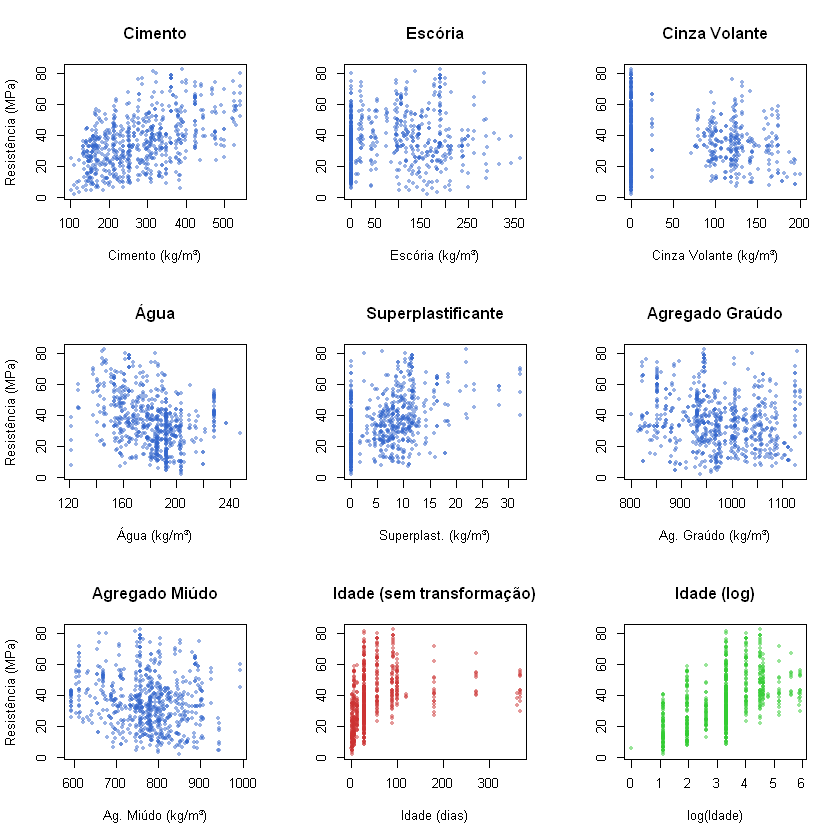

In [97]:
par(mfrow = c(3, 3))
plot(dados_treino$Cimento, dados_treino$Resistencia,
     main = "Cimento", xlab = "Cimento (kg/m³)", ylab = "Resistência (MPa)",
     pch = 16, col = rgb(0.2, 0.4, 0.8, 0.5), cex = 0.7)

plot(dados_treino$Escoria, dados_treino$Resistencia,
     main = "Escória", xlab = "Escória (kg/m³)", ylab = "",
     pch = 16, col = rgb(0.2, 0.4, 0.8, 0.5), cex = 0.7)

plot(dados_treino$CinzaVolante, dados_treino$Resistencia,
     main = "Cinza Volante", xlab = "Cinza Volante (kg/m³)", ylab = "",
     pch = 16, col = rgb(0.2, 0.4, 0.8, 0.5), cex = 0.7)

plot(dados_treino$Agua, dados_treino$Resistencia,
     main = "Água", xlab = "Água (kg/m³)", ylab = "Resistência (MPa)",
     pch = 16, col = rgb(0.2, 0.4, 0.8, 0.5), cex = 0.7)

plot(dados_treino$Superplastificante, dados_treino$Resistencia,
     main = "Superplastificante", xlab = "Superplast. (kg/m³)", ylab = "",
     pch = 16, col = rgb(0.2, 0.4, 0.8, 0.5), cex = 0.7)

plot(dados_treino$AgregadoGraudo, dados_treino$Resistencia,
     main = "Agregado Graúdo", xlab = "Ag. Graúdo (kg/m³)", ylab = "",
     pch = 16, col = rgb(0.2, 0.4, 0.8, 0.5), cex = 0.7)

plot(dados_treino$AgregadoMiudo, dados_treino$Resistencia,
     main = "Agregado Miúdo", xlab = "Ag. Miúdo (kg/m³)", ylab = "Resistência (MPa)",
     pch = 16, col = rgb(0.2, 0.4, 0.8, 0.5), cex = 0.7)

plot(dados_treino$Idade, dados_treino$Resistencia,
     main = "Idade (sem transformação)", xlab = "Idade (dias)", ylab = "",
     pch = 16, col = rgb(0.8, 0.2, 0.2, 0.5), cex = 0.7)
# curva completamente não linear

plot(log(dados_treino$Idade), dados_treino$Resistencia,
     main = "Idade (log)", xlab = "log(Idade)", ylab = "",
     pch = 16, col = rgb(0.2, 0.8, 0.2, 0.5), cex = 0.7)
# Nota: Muito mais linear!
par(mfrow = c(1, 1))

#### 1.4 Análise descritiva das covariáveis 

| Variável | Min. | 1st Qu. | Median | Mean | 3rd Qu. | Max. |
|-----------|------|----------|---------|------|----------|------|
| Cimento | 102.0 | 192.0 | 266.0 | 280.4 | 350.0 | 540.0 |
| Escoria | 0.00 | 0.00 | 42.08 | 78.34 | 145.00 | 359.40 |
| CinzaVolante | 0.00 | 0.00 | 0.00 | 52.71 | 118.27 | 200.00 |
| Agua | 121.8 | 164.9 | 185.7 | 181.8 | 193.0 | 246.9 |
| Superplastificante | 0.000 | 0.000 | 6.470 | 6.298 | 10.160 | 32.200 |
| AgregadoGraudo | 801.0 | 932.0 | 968.0 | 972.4 | 1028.4 | 1134.3 |
| AgregadoMiudo | 594.0 | 724.3 | 778.5 | 771.0 | 821.0 | 992.6 |
| Idade | 1.00 | 7.00 | 28.00 | 45.83 | 56.00 | 365.00 |
| Resistencia | 2.332 | 24.065 | 34.770 | 36.090 | 45.940 | 82.599 |

---


In [98]:
summary(dados_treino)

    Cimento         Escoria        CinzaVolante         Agua      
 Min.   :102.0   Min.   :  0.00   Min.   :  0.00   Min.   :121.8  
 1st Qu.:192.0   1st Qu.:  0.00   1st Qu.:  0.00   1st Qu.:164.9  
 Median :266.0   Median : 42.08   Median :  0.00   Median :185.7  
 Mean   :280.4   Mean   : 78.34   Mean   : 52.71   Mean   :181.8  
 3rd Qu.:350.0   3rd Qu.:145.00   3rd Qu.:118.27   3rd Qu.:193.0  
 Max.   :540.0   Max.   :359.40   Max.   :200.00   Max.   :246.9  
 Superplastificante AgregadoGraudo   AgregadoMiudo       Idade       
 Min.   : 0.000     Min.   : 801.0   Min.   :594.0   Min.   :  1.00  
 1st Qu.: 0.000     1st Qu.: 932.0   1st Qu.:724.3   1st Qu.:  7.00  
 Median : 6.470     Median : 968.0   Median :778.5   Median : 28.00  
 Mean   : 6.298     Mean   : 972.4   Mean   :771.0   Mean   : 45.83  
 3rd Qu.:10.160     3rd Qu.:1028.4   3rd Qu.:821.0   3rd Qu.: 56.00  
 Max.   :32.200     Max.   :1134.3   Max.   :992.6   Max.   :365.00  
  Resistencia    
 Min.   : 2.332  
 1st 

#### 1.5 Conclusão da Etapa 1

* A base de treino tem 721 observações.

* Não aparenta ter inconsistências nos dados

---

## Etapa 2:

---
*Para a base da nossa análise, deve se verificar as seguintes coisas:*

* Redução de dimensão das covariáveis (Parcimonia)
* Matriz de correlação
* Multicolinearidade, usando critério de VIF (Variance Inflation Factor) como medida
* Seleção de variáveis

*Qual o ponto dessa etapa? Preparar as covariáveis para o ajuste. *

***Covariáveis IMPORTANTES/RELEVANTES***

---


#### 2.1 Corrplot das variáveis

![Corrplot das variaveis](2_1_corrplot.png)

A matriz de correlação não revela correlações muito fortes entre as variáveis preditoras (todas as correlações entre pares de preditores são menores que 0,7 em valor absoluto). Isso sugere **ausência de multicolinearidade** problemática, indicando que as covariáveis são aproximadamente linearmente independentes entre si. Porém, pode haver restrição estrutural nos dados: quando $X_1$ pode ser "reconstruído" por combinações de $X_2 + X_3 + X_4...$


---

[1] "Matriz de Correlação:"


,Cimento,Escoria,CinzaVolante,Agua,Superplastificante,AgregadoGraudo,AgregadoMiudo,Idade,Resistencia
Cimento,1.00,-0.26,-0.44,-0.08,0.11,-0.09,-0.20,0.13,0.50
Escoria,-0.26,1.00,-0.30,0.06,0.08,-0.30,-0.29,-0.09,0.16
CinzaVolante,-0.44,-0.30,1.00,-0.22,0.33,-0.02,0.08,-0.15,-0.13
Agua,-0.08,0.06,-0.22,1.00,-0.66,-0.18,-0.45,0.28,-0.31
Superplastificante,0.11,0.08,0.33,-0.66,1.00,-0.26,0.22,-0.19,0.40
AgregadoGraudo,-0.09,-0.30,-0.02,-0.18,-0.26,1.00,-0.17,-0.02,-0.16
AgregadoMiudo,-0.20,-0.29,0.08,-0.45,0.22,-0.17,1.00,-0.17,-0.16
Idade,0.13,-0.09,-0.15,0.28,-0.19,-0.02,-0.17,1.00,0.33
Resistencia,0.50,0.16,-0.13,-0.31,0.40,-0.16,-0.16,0.33,1.00


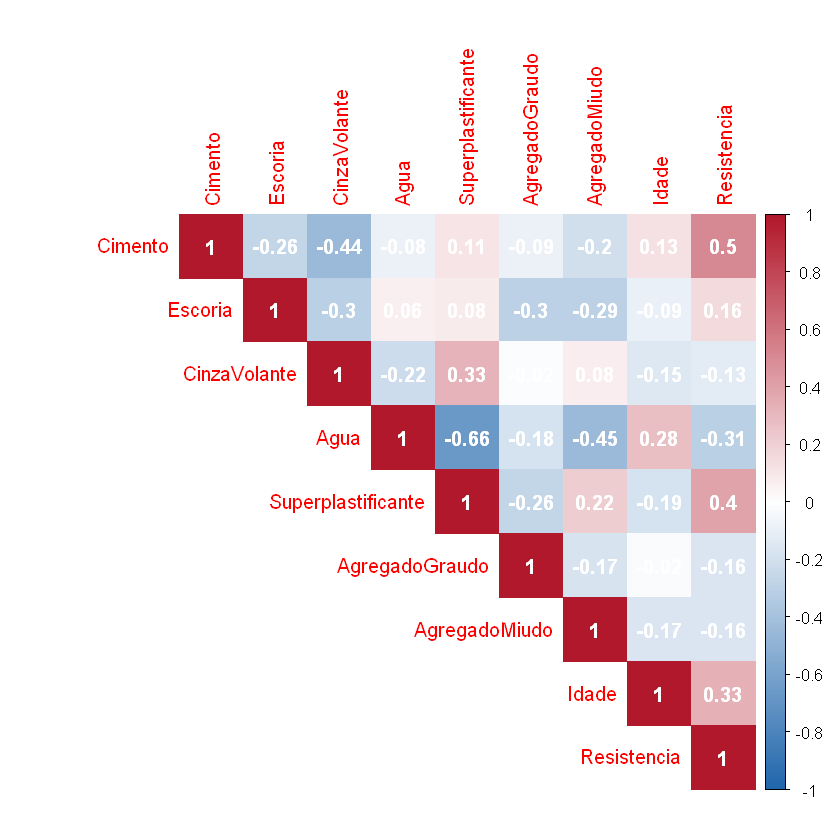

In [99]:
# Matriz de correlação (dados brutos)
library(corrplot)
vars_explicativas <- dados_treino[, c("Cimento", "Escoria", "CinzaVolante", "Agua",
                                      "Superplastificante", "AgregadoGraudo",
                                      "AgregadoMiudo", "Idade", "Resistencia")]

cor_matrix <- cor(vars_explicativas)
print("Matriz de Correlação:")
round(cor_matrix, 2)

# Visualizar matriz de correlação
corrplot(cor_matrix, 
         method = "color",
         type = "upper",
         addCoef.col = "white",
         col = colorRampPalette(c("#2166AC", "white", "#B2182B"))(200))

#### 2.2 Diagnóstico de multicolinearidade usando VIF (Variance Inflation Factor) como medida

Com o modelo full(completo) $Y = X\beta + \varepsilon$, pode-se calcular os VIF's

| | Cimento | Escoria | CinzaVolante | Agua | Superplastificante | AgregadoGraudo | AgregadoMiudo | Idade |
|----|----------|----------|---------------|-------|---------------------|-----------------|----------------|--------|
|**VIF**  | 7.733 | 7.801 | 6.518  | 7.073 | 7.073  | 2.953 | 5.102 | 7.119  |

Os Valores do Fator de Inflação da Variância (VIF) são todos inferiores a 2. Esse resultado confirma a **ausência de multicolinearidade**; não há evidência de que alguma preditora seja combinação linear das demais.

---

In [100]:
library(car)
modelo_completo <- lm(Resistencia ~ Cimento + Escoria + CinzaVolante +
                        Agua + Superplastificante + AgregadoGraudo +
                        AgregadoMiudo + Idade,
                      data = dados_treino)

vif_values <- vif(modelo_completo)

round(vif_values, 3)
# VIF's se tornam consideravelmente mais altos

Cimento            Escoria       CinzaVolante               Agua 
             7.733              7.801              6.518              7.073 
Superplastificante     AgregadoGraudo      AgregadoMiudo              Idade 
             2.953              5.102              7.119              1.146

#### 2.3 Seleção de variáveis

* Stepwise (BIC): a saída em R fica do jeito abaixo


```text

Resistencia ~ Cimento + Escoria + CinzaVolante + Agua + Idade

(Intercept): 34.5938 Cimento: 0.1113 Escoria: 0.0945 CinzaVolante: 0.0814 Agua: -0.2559 Idade: 0.1119

```

O método stepwise (BIC) partiu do modelo nulo e 
adicionou/removeu termos até encontrar o modelo com menor BIC. O modelo selecionado contém 
**Cimento, Escoria,  CinzaVolante,  Agua, Idade**. As covariáves Superplastificante, AgregadoGraudo e AgregadoMiudo foram excluídas.

In [101]:
library(MASS)
# Seleção por BIC (Stepwise)
modelo_step_BIC <- stepAIC(modelo_completo, direction = "both",
                           k = log(nrow(dados_treino)), trace = FALSE)
# Modelo selecionado por BIC:")
formula(modelo_step_BIC)
round(coef(modelo_step_BIC), 4)

Resistencia ~ Cimento + Escoria + CinzaVolante + Agua + Idade

(Intercept)      Cimento      Escoria CinzaVolante         Agua        Idade 
     34.5938       0.1113       0.0945       0.0814      -0.2559       0.1119

* Cp de Mallows:
```text
Selection Algorithm: exhaustive
         Cimento Escoria CinzaVolante Agua Superplastificante AgregadoGraudo
1  ( 1 ) "*"     " "     " "          " "  " "                " "           
2  ( 1 ) "*"     " "     " "          " "  "*"                " "           
3  ( 1 ) "*"     " "     " "          " "  "*"                " "           
4  ( 1 ) "*"     "*"     " "          "*"  " "                " "           
5  ( 1 ) "*"     "*"     "*"          "*"  " "                " "           
6  ( 1 ) "*"     "*"     "*"          "*"  "*"                " "           
7  ( 1 ) "*"     "*"     "*"          "*"  "*"                "*"           
8  ( 1 ) "*"     "*"     "*"          "*"  "*"                "*"           
...
5  ( 1 ) " "           "*"  
6  ( 1 ) " "           "*"  
7  ( 1 ) " "           "*"  
8  ( 1 ) "*"           "*" 
......
```

|# de covariável | 1  | 2  | 3  | 4  |5  |6  |7  |8  |  
| :--- | :---: | :---: | :---: | :---: |:---: |:---: |:---: |:---: |
| **Cp de Mallows** |723.826  | 500.483 |  271.826  | 114.138 |13.184 |9.307|10.798|9.000|


O modelo com menor Cp é o de 8 variáveis, mas o de 6 (Resistencia ~ Cimento + Escoria + CinzaVolante + Agua + Superplastificante + Idade) é próximo também.

![gráfico dos valores de cp de mallows conforme aumenta # de covariaveis.png](2_3_cp_mallows.png)


---

Subset selection object
Call: regsubsets.formula(Resistencia ~ Cimento + Escoria + CinzaVolante + 
    Agua + Superplastificante + AgregadoGraudo + AgregadoMiudo + 
    Idade, data = dados_treino, nbest = 1, nvmax = 8)
8 Variables  (and intercept)
                   Forced in Forced out
Cimento                FALSE      FALSE
Escoria                FALSE      FALSE
CinzaVolante           FALSE      FALSE
Agua                   FALSE      FALSE
Superplastificante     FALSE      FALSE
AgregadoGraudo         FALSE      FALSE
AgregadoMiudo          FALSE      FALSE
Idade                  FALSE      FALSE
1 subsets of each size up to 8
Selection Algorithm: exhaustive
         Cimento Escoria CinzaVolante Agua Superplastificante AgregadoGraudo
1  ( 1 ) "*"     " "     " "          " "  " "                " "           
2  ( 1 ) "*"     " "     " "          " "  "*"                " "           
3  ( 1 ) "*"     " "     " "          " "  "*"                " "           
4  ( 1 ) "*"     "*" 

n_vars,Cp,R2,R2_adj,BIC
<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,723.826,0.2546,0.2536,-198.70
2,500.483,0.3712,0.3694,-314.74
3,271.826,0.4905,0.4884,-459.88
4,114.138,0.5731,0.5707,-580.86
5,13.184,0.6264,0.6238,-670.37
6,9.307,0.6294,0.6263,-669.68
7,10.798,0.6297,0.6261,-663.61
8,9.000,0.6317,0.6275,-660.86


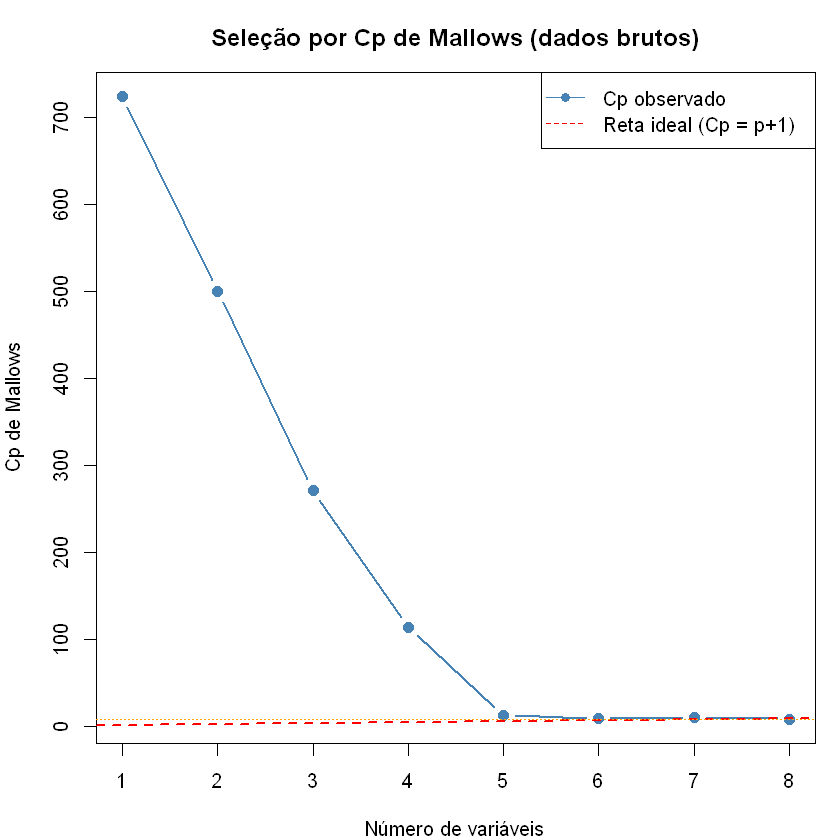

In [102]:
library(leaps)
# Seleção por Cp de mallows
reg_sub <- regsubsets(Resistencia ~ Cimento + Escoria + CinzaVolante +
                        Agua + Superplastificante + AgregadoGraudo +
                        AgregadoMiudo + Idade,
                      data = dados_treino, nbest = 1, nvmax = 8)

resumo_sub <- summary(reg_sub)
print(resumo_sub)

tabela_mallows <- data.frame(
  "n_vars" = 1:8,
  "Cp" = round(resumo_sub$cp, 3),
  "R2" = round(resumo_sub$rsq, 4),
  "R2_adj" = round(resumo_sub$adjr2, 4),
  "BIC" = round(resumo_sub$bic, 2)
)

# Seleção por Cp de Mallows
tabela_mallows
par(mar = c(4, 4, 3, 1))
plot(1:8, resumo_sub$cp, type = "b", pch = 16, cex = 1.2,
     xlab = "Número de variáveis", ylab = "Cp de Mallows",
     main = "Seleção por Cp de Mallows (dados brutos)", col = "steelblue", lwd = 2)
abline(a = 1, b = 1, col = "red", lty = 2, lwd = 2)
abline(h = 9, col = "orange", lty = 3, lwd = 1.5)
legend("topright", c("Cp observado", "Reta ideal (Cp = p+1)"),
       col = c("steelblue", "red"), lty = c(1, 2), pch = c(16, NA))

* LASSO: 

```text
9 x 1 sparse Matrix of class "dgCMatrix"
                     lambda.min
(Intercept)        -26.91760181
Cimento              0.12112049
Escoria              0.10713827
CinzaVolante         0.09109392
Agua                -0.14727340
Superplastificante   0.29303701
AgregadoGraudo       0.01968407
AgregadoMiudo        0.02137302
Idade                0.11263026
```
O LASSO reteve todas as covariáveis, e atribui valores baixos de $\lambda$ para AgregadiGraudo e AgregadoMiudo.

---

In [103]:
library(glmnet)
# Seleção por Lasso
X_mat <- model.matrix(Resistencia ~ Cimento + Escoria + CinzaVolante +
                        Agua + Superplastificante + AgregadoGraudo +
                        AgregadoMiudo + Idade,
                      data = dados_treino)[, -1]

y_vec <- dados_treino$Resistencia
set.seed(42)

cv_lasso <- cv.glmnet(X_mat, y_vec, alpha = 1)

#plot(cv_lasso, main = "Lasso: Validação Cruzada para seleção de λ (dados brutos)")

coef_lasso_min <- coef(cv_lasso, s = "lambda.min")
coef_lasso_min
vars_lasso <- names(which(coef_lasso_min[-1, 1] != 0))
# Variáveis selecionadas por Lasso:
vars_lasso

9 x 1 sparse Matrix of class "dgCMatrix"
                     lambda.min
(Intercept)        -26.91760181
Cimento              0.12112049
Escoria              0.10713827
CinzaVolante         0.09109392
Agua                -0.14727340
Superplastificante   0.29303701
AgregadoGraudo       0.01968407
AgregadoMiudo        0.02137302
Idade                0.11263026

[1] "Cimento"            "Escoria"            "CinzaVolante"      
[4] "Agua"               "Superplastificante" "AgregadoGraudo"    
[7] "AgregadoMiudo"      "Idade"

In [104]:
library(ggplot2)
library(readxl)
library(GGally)      
library(car)         
library(lmtest)      
library(nortest)     
library(MASS)        
library(leaps)       
library(glmnet)   

Então pelas resultados de Step(BIC) e Cp de Mallow e parcimonia, o modelo terá 6 covariáveis (Resistencia ~ Cimento + Escoria + CinzaVolante + Agua + Superplastificante + Idade).

#### 2.4 Conclusão da Etapa 2

* A Matriz de Correlação não mostrou correlações elevadas entre preditoras, mas com o modelo full (completo) alguns valores de VIFs são razoavelmente elevados sugere um certo nível de multicolinearidade. 

* Na seleção de variáveis, o método Stepwise(BIC) reteve Cimento, Escoria, CinzaVolante, Agua, e Idade; o Cp de Mallows reteve as mesmas covariáveis mais a covariável Superplastificante . 

* Em respeito aos métodos usados (Stepwise, Cp e LASSO), selecionamos para a etapa seguinte **o modelo com Resistencia ~ Cimento + Escoria + CinzaVolante + Agua + Superplastificante + Idade**.”

---

## Etapa 3:

1. Ajustar o modelo
2. Fazer Diagnóstico/ análise de resíduo para verificar os pressupostos:
* Lineraridade (gráfico de resíduos vs. valores ajustados)
* Homocedasticidade (o mesmo gráfico + teste de Breusch-Pagan ou outros testes)
* Normalidade dos erros (QQ-plot + teste de Shapiro-Wilk ou outros)
* Independência (gráfico de resíduos vs. ordem de coleta, nesse caso não temos a ordem)

3. Se passar pelo crivo da análise de resíduo --> prossiga
4. Inclua a parte de detecção de outliers e pontos influentes. Opções: $H_{ii}$; DF-Betas; DF-Fits; D-Cook
5. Após análise de resíduo faça testes.

---

#### 3.1 Ajuste do modelo

Pela etapa 2, o modelo é da forma

$Y$ = $\text{Resistência à compressão} = {\beta}_0 + {\beta}_1 \text{Cimento}  + {\beta}_2 \text{Escoria} + {\beta}_3 \text{CinzaVolante}+ {\beta}_4 \text{Agua} + {\beta}_5 \text{Superplastificante} + {\beta}_6 {Idade} + \varepsilon $ 

onde $\varepsilon_{ij}$ são iid e seguem distribuição normal com média zero, e variancia $\sigma^2$

```
Call:
lm(formula = Resistencia ~ Cimento + Escoria + CinzaVolante + 
    Agua + Superplastificante + Idade, data = dados_treino)
Residuals:
    Min      1Q  Median      3Q     Max 
-29.277  -6.316   0.273   6.450  34.538 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)        28.885497   4.935315   5.853 7.37e-09 ***
Cimento             0.106108   0.005244  20.232  < 2e-16 ***
Escoria             0.088490   0.005836  15.163  < 2e-16 ***
CinzaVolante        0.070523   0.009198   7.667 5.76e-14 ***
Agua               -0.218949   0.024562  -8.914  < 2e-16 ***
Superplastificante  0.238821   0.098670   2.420   0.0158 *  
Idade               0.111404   0.006350  17.544  < 2e-16 ***

... ...
```

* Coeficientes estimados: $\hat{\beta_0} = 28.88$, $\hat{\beta_1} = 0.10$, $\hat{\beta_2} = 0.09$, $\hat{\beta_3}$ = 0.07, $\hat{\beta_4}$ = -0.21, $\hat{\beta_5}$ = 0.24, $\hat{\beta_6}$ = 0.11

Interpretação: 

${\beta_0}$: Não tem interpretação para $\beta_0$ pois aparentemente 0 não está no range das covariáveis (se não tem componentes, não tem concreto, consequentemente não tem resistência à compressão).

$\hat{\beta_1}$: Para cada kg de Cimento adicional em 1 $m^3$ de concreto, estima-se um aumento de 4% em média na resistência do concreto , mantendo as outras covariáveis fixas;

A mesma interpretação pode ser feita com $\hat{\beta_2}$, $\hat{\beta_3}$, $\hat{\beta_4}$, $\hat{\beta_5}$, uma vez que são componentes do concreto também.

$\hat{\beta_6}$: Para cada dia adicional na Idade do concreto (range = [1,180]), estima-se um aumento de 11% em média na resistência do concreto , mantendo as outras covariáveis fixas;

#### 3.1.1 VIFs do modelo reduzido

| | Cimento | Escoria | CinzaVolante | Agua | Superplastificante |  Idade |
|----|----------|----------|---------------|-------|---------------------|-----------------|
|**VIF**  | 2.012 | 1.75 | 2.348  | 1.958 | 2.455  | 1.124 | 


---


In [105]:
modelo <- lm(Resistencia ~ Cimento + Escoria + CinzaVolante +
                     Agua + Superplastificante + Idade,
                   data = dados_treino)

summary(modelo) 

vif_values <- vif(modelo)
round(vif_values, 3)


Call:
lm(formula = Resistencia ~ Cimento + Escoria + CinzaVolante + 
    Agua + Superplastificante + Idade, data = dados_treino)

Residuals:
    Min      1Q  Median      3Q     Max 
-29.277  -6.316   0.273   6.450  34.538 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)        28.885497   4.935315   5.853 7.37e-09 ***
Cimento             0.106108   0.005244  20.232  < 2e-16 ***
Escoria             0.088490   0.005836  15.163  < 2e-16 ***
CinzaVolante        0.070523   0.009198   7.667 5.76e-14 ***
Agua               -0.218949   0.024562  -8.914  < 2e-16 ***
Superplastificante  0.238821   0.098670   2.420   0.0158 *  
Idade               0.111404   0.006350  17.544  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 10.3 on 714 degrees of freedom
Multiple R-squared:  0.6294,	Adjusted R-squared:  0.6263 
F-statistic: 202.1 on 6 and 714 DF,  p-value: < 2.2e-16


Cimento            Escoria       CinzaVolante               Agua 
             2.012              1.750              2.348              1.958 
Superplastificante              Idade 
             2.455              1.124

#### 3.2 Diagnóstico/ Análise de resíduos

##### 3.2.1 Independência

Como não temos a ordem da coleta, assume-se a independência.

(Claro, supondo que o índice dos dados sejam a ordem, podemos fazer um teste de Durbin-Watson, que daria um valor-p de 0.56.)

```
        Durbin-Watson test

data:  modelo_final
DW = 2.0125, p-value = 0.5691
alternative hypothesis: true autocorrelation is greater than 0

```



##### 3.2.2 Gráficos

Abaixo temos um QQ-plote um gráfico de resíduos vs valores ajustados.

![QQplot e Gráfico de resíduos vs valores ajustados](3_2_QQplot_residuo_vs_ajustadoe.png)

O gráfico de resíduos vs valores ajustados, aparenta ter alguma estrutura de funil, isso pode indicar que talvez uma trasformação seja necessária. Agora vamos prosseguir para os testes de pressupostos.

---

##### 3.2.3 Testes de normalidade e homocedasticidade

```
	Shapiro-Wilk normality test

data:  residuos
W = 0.99671, p-value = 0.1453

	studentized Breusch-Pagan test

data:  modelo
BP = 104.01, df = 6, p-value < 2.2e-16
```

Teste de Shapiro-Wilk deu um valor-p de 0.14, não é pequeno, suposição da normalidade não é violada.

Teste de Breusch-Pagan deu um valor-p extremamente pequeno, suposição da homocedasticidade é violada ---> problema.


##### 3.2.3.1 Problema da homocedasticidade

O resultado do teste de Breusch-Pagan indica que uma transformação pode ser necessária (ou até interações).

Foram feitas as seguintes possibilidades:

* $\log(\text{Resistência à compressão}) =  {\beta}_0 + {\beta}_1 \text{Cimento}  + {\beta}_2 \text{Escoria} + {\beta}_3 \text{CinzaVolante}+ {\beta}_4 \text{Agua} + {\beta}_5 \text{Superplastificante} + {\beta}_6 {Idade} + \varepsilon $ 

* $(\text{Resistência à compressão})^2 =  {\beta}_0 + {\beta}_1 \text{Cimento}  + {\beta}_2 \text{Escoria} + {\beta}_3 \text{CinzaVolante}+ {\beta}_4 \text{Agua} + {\beta}_5 \text{Superplastificante} + {\beta}_6 {Idade} + \varepsilon $ 

* $\sqrt{(\text{Resistência à compressão})} =  {\beta}_0 + {\beta}_1 \text{Cimento}  + {\beta}_2 \text{Escoria} + {\beta}_3 \text{CinzaVolante}+ {\beta}_4 \text{Agua} + {\beta}_5 \text{Superplastificante} + {\beta}_6 {Idade} + \varepsilon $ 

* $\frac{1}{(\text{Resistência à compressão})} =  {\beta}_0 + {\beta}_1 \text{Cimento}  + {\beta}_2 \text{Escoria} + {\beta}_3 \text{CinzaVolante}+ {\beta}_4 \text{Agua} + {\beta}_5 \text{Superplastificante} + {\beta}_6 {Idade} + \varepsilon $ 

As quatro transformações usuais acima não foram úteis para satisfazer o pressuposto de homocedasticidade. Mas conseguimos achar uma que é assim:

* $\sqrt{(\text{Resistência à compressão})} =  {\beta}_0 + {\beta}_1 \text{Cimento}  + {\beta}_2 \text{Escoria} + {\beta}_3 \text{CinzaVolante}+ {\beta}_4 \text{Agua} + {\beta}_5 \text{Superplastificante} + {\beta}_6 \log{\text{(Idade)}} + {\beta}_7 (\log{\text{Idade}})^2 + \varepsilon $ 

Essa transformação atende os pressupostos, porém, pelo princípio da parcimonia e manter o valor pedagógico desse trabalho, decidimos não fazer a análise com o modelo transformado por enquanto. Agora vamos fingir que a homocedasticidade do modelo original é satisfeita e prosseguir.



	Shapiro-Wilk normality test

data:  residuos
W = 0.99671, p-value = 0.1453



	studentized Breusch-Pagan test

data:  modelo
BP = 104.01, df = 6, p-value < 2.2e-16


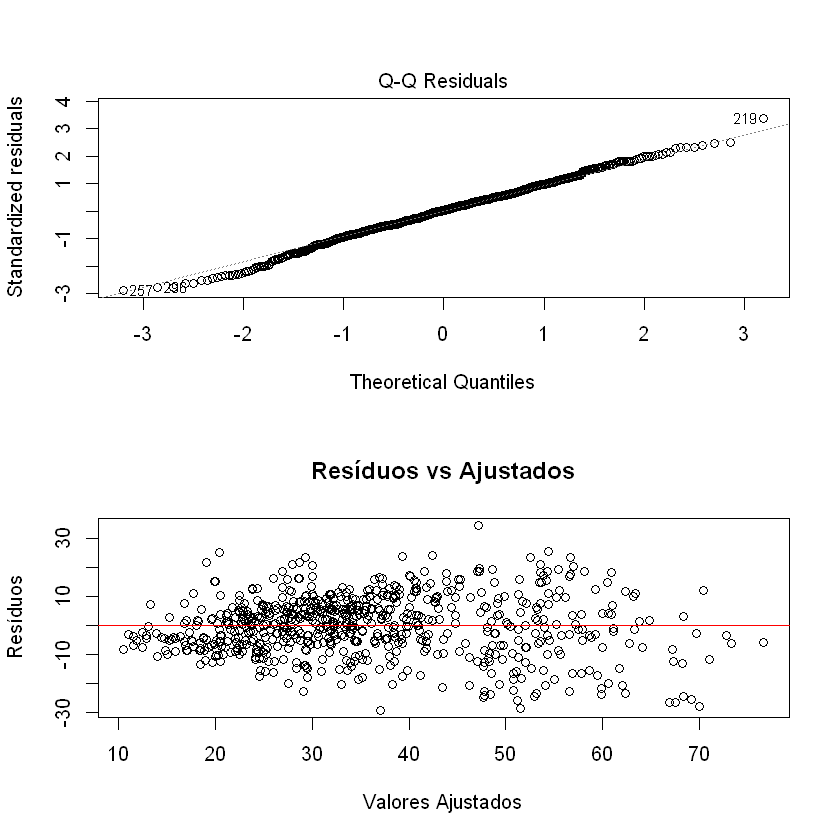

In [106]:
library(lmtest)
residuos <- residuals(modelo)
ajustados <- fitted(modelo)

par(mfrow = c(2, 1))

plot(modelo, which = 2)
plot(ajustados, residuos,
     xlab = "Valores Ajustados", ylab = "Resíduos",
     main = "Resíduos vs Ajustados")
abline(h = 0, col = "red")

par(mfrow = c(1, 1))
# indicativo de heterocedasticidade com afunilamento no grafico Residuals vs Fitted
# Indicio de normalidade através do QQplot, respeitando bem a linha

shapiro.test(residuos)
bptest(modelo)


In [107]:
dados_treino$log_Resistencia <- log(dados_treino$Resistencia)
modelo_log <- lm(log_Resistencia ~ Cimento + Escoria + CinzaVolante +
                     Agua + Superplastificante + Idade,
                   data = dados_treino)

bptest(modelo_log)         

dados_treino$quad_Resistencia <- (dados_treino$Resistencia)^2
modelo_quad <- lm(quad_Resistencia ~ Cimento + Escoria + CinzaVolante +
                     Agua + Superplastificante + Idade,
                   data = dados_treino)

bptest(modelo_quad)   

dados_treino$raiz_Resistencia <- sqrt(dados_treino$Resistencia)
modelo_raiz <- lm(raiz_Resistencia ~ Cimento + Escoria + CinzaVolante +
                     Agua + Superplastificante + Idade,
                   data = dados_treino)

bptest(modelo_raiz)  

dados_treino$inv_Resistencia <- (dados_treino$Resistencia)^(-1)
modelo_inv <- lm(inv_Resistencia ~ Cimento + Escoria + CinzaVolante +
                     Agua + Superplastificante + Idade,
                   data = dados_treino)

bptest(modelo_inv) 


	studentized Breusch-Pagan test

data:  modelo_log
BP = 42.526, df = 6, p-value = 1.448e-07



	studentized Breusch-Pagan test

data:  modelo_quad
BP = 191.37, df = 6, p-value < 2.2e-16



	studentized Breusch-Pagan test

data:  modelo_raiz
BP = 27.727, df = 6, p-value = 0.0001058



	studentized Breusch-Pagan test

data:  modelo_inv
BP = 29.121, df = 6, p-value = 5.772e-05


#### 3.3 Análise de outliers e pontos influentes

##### 3.3.1 Resíduos studentized e alavancagem (os $H_{ii}$)

![Gráfico de residuos studentized.png](3_3_1_residuo_studentized.png)



```
Outliers (resíduo studentizado > |3|): 219 
# A tibble: 1 × 13
  Cimento Escoria CinzaVolante  Agua Superplastificante AgregadoGraudo
    <dbl>   <dbl>        <dbl> <dbl>              <dbl>          <dbl>
1     315     137            0   145                5.9           1130

```

Apenas uma observação apresentou resíduo padronizado acima de |3|,
indicando ausência de grande quantidade de outliers extremos.
Isso sugere que o modelo não está sendo fortemente afetado por
observações discrepantes na variável resposta.

![Os hat values ordenados.png](3_3_1_hii_ordem.png)

Foram identificadas 57 observações com leverage ($h_{ii}$) acima do limiar 2p/n,
indicando pontos com combinações incomuns das variáveis explicativas.
Porém, leverage alto não implica necessariamente influência
significativa sobre o ajuste do modelo. 

Mas, se usarmos outro o segundo criterio (limiar = 1/2), temos 0 pontos

[1] 1

219 
219

Possíveis outliers (resíduo studentizado > |3|): 219 
# A tibble: 1 × 13
  Cimento Escoria CinzaVolante  Agua Superplastificante AgregadoGraudo
    <dbl>   <dbl>        <dbl> <dbl>              <dbl>          <dbl>
1     315     137            0   145                5.9           1130
# ℹ 7 more variables: AgregadoMiudo <dbl>, Idade <dbl>, Resistencia <dbl>,
#   log_Resistencia <dbl>, quad_Resistencia <dbl>, raiz_Resistencia <dbl>,
#   inv_Resistencia <dbl>


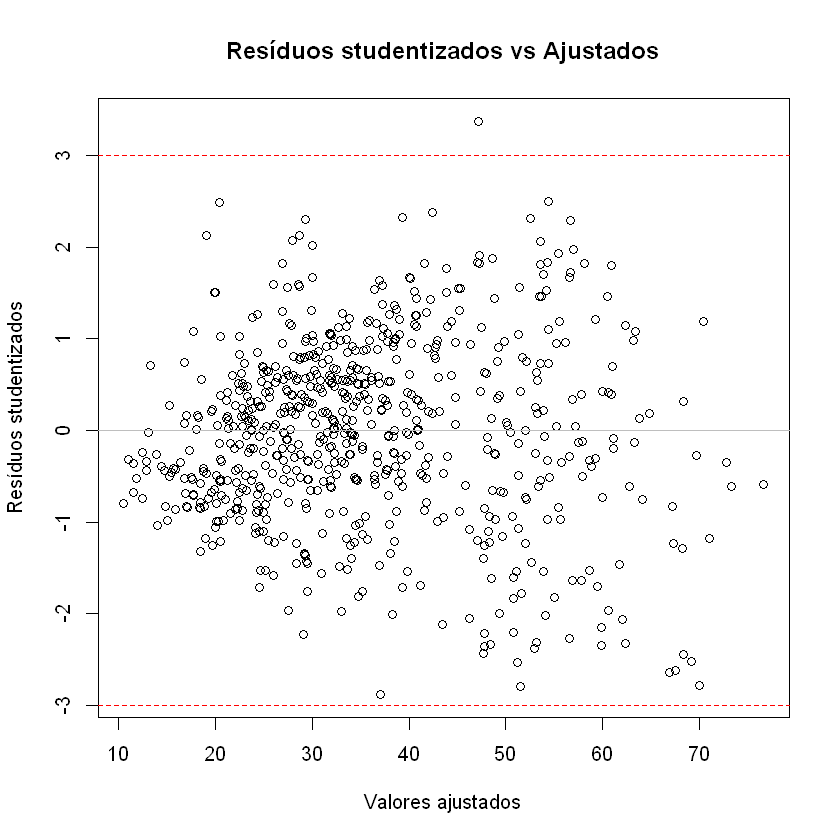

In [108]:
res_std <- rstandard(modelo)
outliers_idx <- which(abs(res_std) > 3)
length(outliers_idx)
# Índices dos outliers:
outliers_idx

outliers_idx <- which(abs(res_std) > 3)
if(length(outliers_idx) > 0) {
  cat("Possíveis outliers (resíduo studentizado > |3|):", outliers_idx, "\n")
  print(dados_treino[outliers_idx, ])
} else {
  cat("Nenhum outlier grave detectado.\n")
}

plot(fitted(modelo), res_std,
     xlab = "Valores ajustados", ylab = "Resíduos studentizados",
     main = "Resíduos studentizados vs Ajustados")
abline(h = c(-3, 0, 3), lty = c(2,1,2), col = c("red","gray","red"))

[1] 0.0194

[1] 57

[1] 0.5

[1] 0

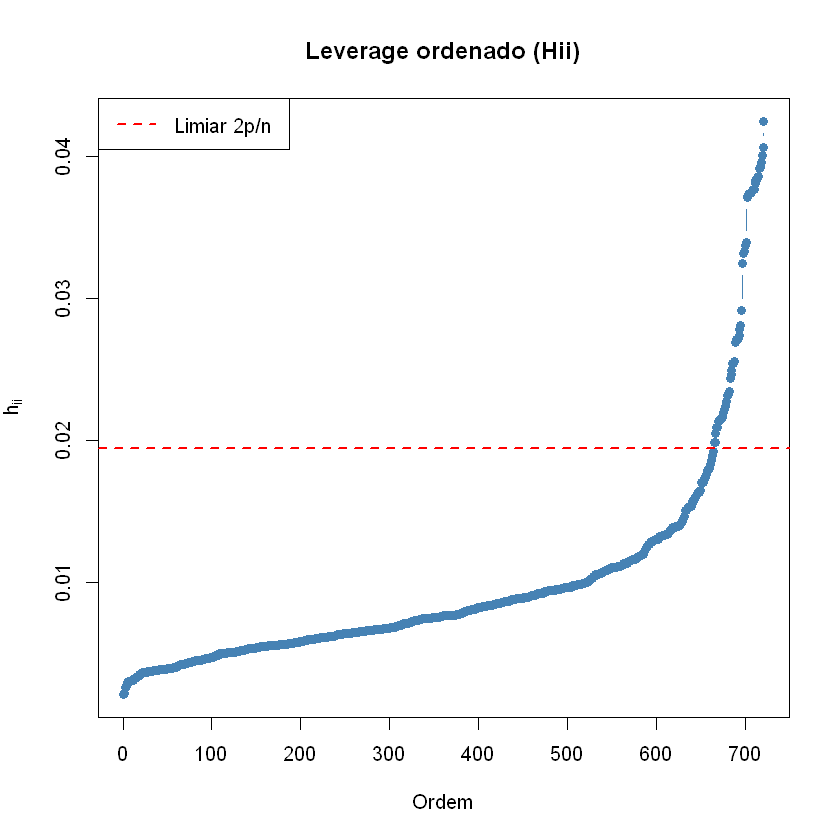

In [109]:
# Hii (Hat Values)

#essa observação possui valores de X incomuns?
#apenas variaveis explicativas entram no calculo
#exemplo, cimentos aparecendo com idade entre 7 e 90 e do nada um aparece com 365
#Mesmo que o modelo preveja bem esse ponto: ele estará longe geometricamente dos outros
#portanto terá leverage alto.
#é importante pois ele pode puxar a reta de regressão;

n <- nrow(dados_treino)
p <- length(coef(modelo))

#1o critério:
leverage <- hatvalues(modelo)
limiar_leverage <- 2 * p / n  
high_leverage <- which(leverage > limiar_leverage)
# Limiar usado:
round(limiar_leverage, 4)
# Número de pontos com alto leverage:
length(high_leverage)

# Foram identificadas 57 observações com leverage acima do limiar 2p/n,
# indicando pontos com combinações incomuns das variáveis explicativas.
# Porem, leverage alto não implica necessariamente influência
# significativa sobre o ajuste do modelo. 

#segundo critério:
leverage2 <- hatvalues(modelo)
limiar_leverage2 <- 1/2  
high_leverage2 <- which(leverage2 > limiar_leverage2)
# Limiar usado:
round(limiar_leverage2, 4)
# Número de pontos com alto leverage:
length(high_leverage2)
#com o segundo criterio, temos 0 pontos

#terceiro criterio:
# Ordenando os valores
lev_ordenado <- sort(leverage)
# Índices na ordem crescente
ordem <- 1:length(lev_ordenado)
# Gráfico
plot(ordem, lev_ordenado,
     type = "b",
     pch = 16,
     col = "steelblue",
     xlab = "Ordem",
     ylab = expression(h[ii]),
     main = "Leverage ordenado (Hii)")

# Linha de referência 2p/n
abline(h = 2 * length(coef(modelo)) / nrow(dados_treino),
       col = "red",
       lty = 2,
       lwd = 2)

legend("topleft",
       legend = c("Limiar 2p/n"),
       col = c("red"),
       lty = 2,
       lwd = 2)

#Leverage alto sozinho nao garante outlier problematico. Um ponto pode tá longe e
#ainda seguir perfeitamente a reta

##### 3.3.2 Distância de Cook

Distância de Cook mede influência global, serve para identificar observações que "puxam" ou desviam a linha de regressão.

![Distância de Cook](3_3_2_DCook.png)

Usando o limiar $F_{n,n-p,0.5}$, nenhuma observação apresentou distância de Cook acima do limite formal,
sugerindo ausência de pontos altamente influentes no ajuste global
da regressão.


---

[1] 0.907399

[1] 0

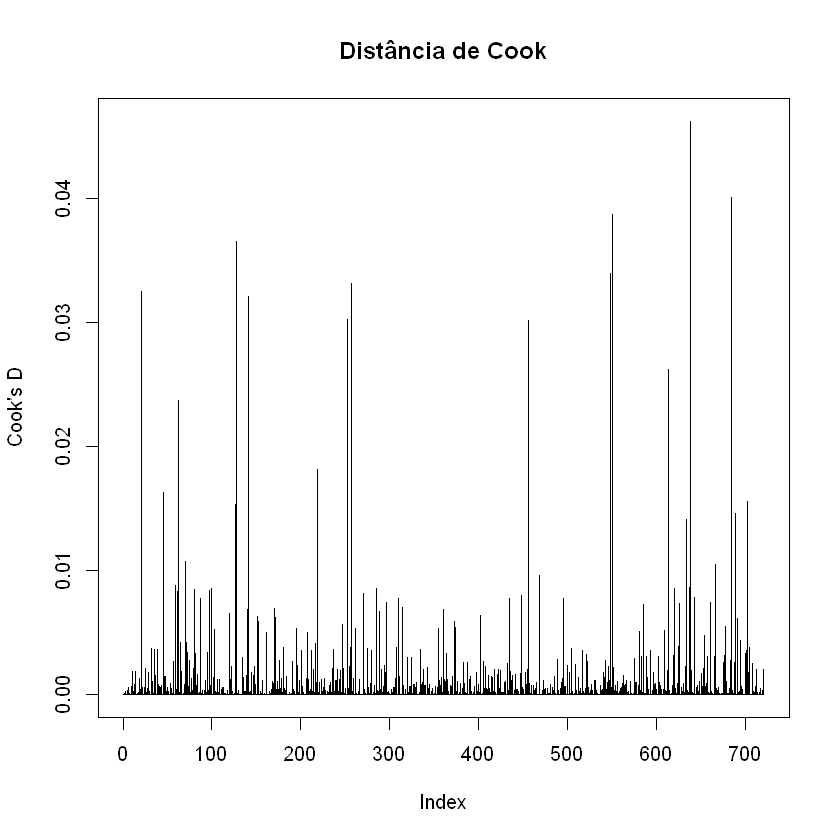

In [110]:
#D-COOK

#se eu remover essa observação, o modelo inteiro muda muito?
# mede influência global.
cooks_d <- cooks.distance(modelo)
cook_limite_formal <- qf(0.5, df1 = p, df2 = n - p)
cook_influentes_formais <- which(cooks_d > cook_limite_formal)

# Limite de Cook Formal 
round(cook_limite_formal, 6)

# Número de pontos influentes 
length(cook_influentes_formais)

# Nenhuma observação apresentou distância de Cook acima do limite formal,
# sugerindo ausência de pontos altamente influentes no ajuste global
# da regressão.

# grafico
plot(cooks_d, type = "h", col = ifelse(cooks_d > cook_limite_formal, "red", "black"),
     main = "Distância de Cook", ylab = "Cook's D")
abline(h = cook_limite_formal, lty = 2, col = "blue")

##### 3.3.3 DFFITS

DFFITS mede impacto no fitted, serve para identificar observações influentes na regressão linear.

![os DFFits](3_3_3_DFFits.png)


Nenhuma observação apresentou DFFITS acima do limite adotado,
indicando ausência de pontos com forte impacto nas predições do modelo.

[1] 2

[1] 0

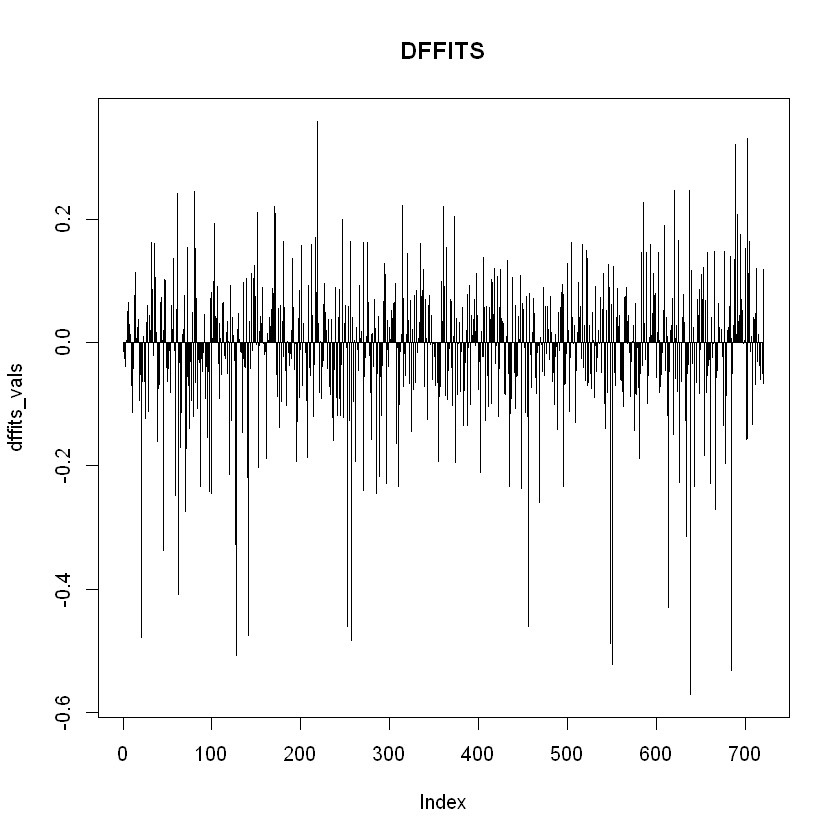

In [111]:
#mede impacto no fitted
dffits_vals <- dffits(modelo)
dffits_limite <- 2  # amostras grandes

abs_dffits <- abs(dffits_vals)
n_dffits <- sum(abs_dffits > dffits_limite)
round(dffits_limite, 4)
n_dffits

plot(dffits_vals, type = "h", col = ifelse(abs(dffits_vals) > dffits_limite, "red", "black"),
     main = "DFFITS")
abline(h = c(-dffits_limite, dffits_limite), lty = 2, col = "blue")
# Nenhuma observação apresentou DFFITS acima do limite adotado,
# indicando ausência de pontos com forte impacto nas predições do modelo.

##### 3.3.4  DFBETAS

DFBETAS medem a influência de cada observação no coeficiente de uma variável.

Nesse caso os DFBETAS não são muito informativos pois na nossa amostra existe concretos constituídos com ausência absoluta de certos componentes, (alguns não tem Escoria, alguns não tem CinzaVolante, alguns não tem Superplastificante).

Enfim, 
O critério DFBETAS identificou 143 observações potencialmente
influentes nos coeficientes.
o limite $\frac{2}{\sqrt{(n)}}$ torna-se bastante sensível em
amostras grandes, resultando na detecção de pequenas alterações
locais nos coeficientes.
o limite ficou 0.0745, qualquer observação que altere um coeficiente em mais de 
0.074 desvios padrão será marcada, muito sensivel.

Mas, testando com o critério alternativo ($|\text{DFBETAS}|>1$), nenhuma observação apresentou DFBETAS acima do limite adotado, nenhuma
altera o coeficiente em mais de 1 erro padrao


In [112]:
# DETECÇÃO DE PONTOS INFLUENTES

#DFBETAS
#essa observação altera muito algum coeficiente β?
dfbetas_vals <- dfbetas(modelo)
dfbetas_limite <- 2/sqrt(n)  

n_dfbetas_total <- sum(rowSums(abs(dfbetas_vals) > dfbetas_limite) > 0)
round(dfbetas_limite, 4)
n_dfbetas_total

# O critério DFBETAS identificou 143 observações potencialmente
# influentes nos coeficientes.
#o limite 2/sqrt(n) torna-se bastante sensível em
# amostras grandes, resultando na detecção de pequenas alterações
# locais nos coeficientes.
#o limite ficou 0.0745, qualquer observação que altere um coeficiente em mais de 
#0.074 desvios padrão será marcada, muito sensivel.


# Testando com o critério alternativo ∣DFBETAS∣>1
# essa observação altera o coeficiente em mais de 1 erro padrão?
# critério complementar mais conservador.
dfbetas_limite2 <- 1  
n_dfbetas_total2 <- sum(rowSums(abs(dfbetas_vals) > dfbetas_limite2) > 0)
round(dfbetas_limite2, 4)
n_dfbetas_total2
# Nenhuma observação apresentou DFBETAS acima do limite adotado, nenhuma
#altera o coeficiente em mais de 1 erro padrao


[1] 0.0745

[1] 143

[1] 1

[1] 0


#### 3.4 Testes de significância formais

##### Fazendo um sumário do modelo com comando "summary" do R, tem-se:

```
Call:
lm(formula = Resistencia ~ Cimento + Escoria + CinzaVolante + 
    Agua + Superplastificante + Idade, data = dados_treino)

Residuals:
    Min      1Q  Median      3Q     Max 
-29.277  -6.316   0.273   6.450  34.538 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)        28.885497   4.935315   5.853 7.37e-09 ***
Cimento             0.106108   0.005244  20.232  < 2e-16 ***
Escoria             0.088490   0.005836  15.163  < 2e-16 ***
CinzaVolante        0.070523   0.009198   7.667 5.76e-14 ***
Agua               -0.218949   0.024562  -8.914  < 2e-16 ***
Superplastificante  0.238821   0.098670   2.420   0.0158 *  
Idade               0.111404   0.006350  17.544  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 10.3 on 714 degrees of freedom
Multiple R-squared:  0.6294,	Adjusted R-squared:  0.6263 
F-statistic: 202.1 on 6 and 714 DF,  p-value: < 2.2e-16

```

Interpretação: 

* As covariáveis são  significativos globalmente (rejeita H0: todos β=0), pois valor-p do teste F Global é pequeno (menor que 2.2e-16)


##### Teste F Parcial

```
Anova Table (Type III tests)

Response: Resistencia
                   Sum Sq  Df  F value    Pr(>F)    
(Intercept)          3634   1  34.2555 7.366e-09 ***
Cimento             43427   1 409.3525 < 2.2e-16 ***
Escoria             24392   1 229.9290 < 2.2e-16 ***
CinzaVolante         6236   1  58.7851 5.762e-14 ***
Agua                 8430   1  79.4597 < 2.2e-16 ***
Superplastificante    621   1   5.8584   0.01575 *  
Idade               32653   1 307.7967 < 2.2e-16 ***
Residuals           75746 714                       
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

```

* Cada linha testa (t) a contribuição de UMA covariável controlando por TODAS as outras
Todos os coeficientes são estatisticamente significativos ao nível de 5%
são as variáveis mais importantes, seguidas por Escória 
(F = 229.93) e Água (F = 79.46). Superplastificante apresenta 
significância marginal (F = 5.86, p = 0.0158), indicando 
contribuição menor mas ainda relevante ao modelo.


In [113]:
summary(modelo)


Call:
lm(formula = Resistencia ~ Cimento + Escoria + CinzaVolante + 
    Agua + Superplastificante + Idade, data = dados_treino)

Residuals:
    Min      1Q  Median      3Q     Max 
-29.277  -6.316   0.273   6.450  34.538 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)        28.885497   4.935315   5.853 7.37e-09 ***
Cimento             0.106108   0.005244  20.232  < 2e-16 ***
Escoria             0.088490   0.005836  15.163  < 2e-16 ***
CinzaVolante        0.070523   0.009198   7.667 5.76e-14 ***
Agua               -0.218949   0.024562  -8.914  < 2e-16 ***
Superplastificante  0.238821   0.098670   2.420   0.0158 *  
Idade               0.111404   0.006350  17.544  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 10.3 on 714 degrees of freedom
Multiple R-squared:  0.6294,	Adjusted R-squared:  0.6263 
F-statistic: 202.1 on 6 and 714 DF,  p-value: < 2.2e-16


In [114]:
anova_tipo3 <- Anova(modelo, type = "III")
print(anova_tipo3)

Anova Table (Type III tests)

Response: Resistencia
                   Sum Sq  Df  F value    Pr(>F)    
(Intercept)          3634   1  34.2555 7.366e-09 ***
Cimento             43427   1 409.3525 < 2.2e-16 ***
Escoria             24392   1 229.9290 < 2.2e-16 ***
CinzaVolante         6236   1  58.7851 5.762e-14 ***
Agua                 8430   1  79.4597 < 2.2e-16 ***
Superplastificante    621   1   5.8584   0.01575 *  
Idade               32653   1 307.7967 < 2.2e-16 ***
Residuals           75746 714                       
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


#### 3.5 Conclusão da Etapa 3


- **Ajuste do modelo**  
  - Modelo múltiplo com 6 variáveis: Cimento, Escória, CinzaVolante, Água, Superplastificante, Idade  
  - R² ajustado = 0,626 → 62,6% da variabilidade da resistência é explicada  
  - Teste F global: F(6,714)=202,1; p<2,2e-16 → modelo globalmente significativo  

- **Significância dos coeficientes**  
  - Todos os coeficientes são estatisticamente significativos (p<0,05)  
  - Destaques: Cimento (t=20,23) e Idade (t=17,54) – maior impacto individual  
  - Superplastificante com significância marginal (p=0,0158)  

- **Multicolinearidade**  
  - VIFs entre 1,12 e 2,45 → sem problemas graves de colinearidade  

- **Verificação dos pressupostos**  
  - **Independência** – Teste de Durbin-Watson: p=0,569 → resíduos independentes  
  - **Normalidade** – Shapiro-Wilk: p=0,145 → normalidade aceita  
  - **Homocedasticidade** – Breusch-Pagan: p<2,2e-16 → **violada** (heterocedasticidade presente)  

- **Tentativas de correção da heterocedasticidade**  
  - Transformações testadas: $\log{Y}$, $Y^2$, $\sqrt{Y}$, $\frac{1}{Y}$ –-> não resolveram  
  - Transformação que funcionou: $\sqrt{(\text{Resistência à compressão})} =  {\beta}_0 + {\beta}_1 \text{Cimento}  + {\beta}_2 \text{Escoria} + {\beta}_3 \text{CinzaVolante}+ {\beta}_4 \text{Agua} + {\beta}_5 \text{Superplastificante} + {\beta}_6 \log{\text{(Idade)}} + {\beta}_7 (\log{\text{Idade}})^2 + \varepsilon $   
  - Por parcimônia e objetivo pedagógico, optou-se por manter o modelo original (ciente da violação)  
  - As interações não foram investigadas pois não somos especialistas em concreto

- **Outliers e pontos influentes**  
  - **Resíduo studentizado** – apenas 1 observação com |res| > 3 (observação 219)  
  - **Alavancagem (hii)** – 57 pontos acima de 2p/n, mas nenhum acima do critério alternativo (1/2)  
  - **Distância de Cook** – nenhum ponto acima do limiar $F_{n,n-p,0.5}$ → sem influência global  
  - **DFFITS** – nenhum ponto acima do limite → sem impacto forte nas predições  
  - **DFBETAS** – 143 pontos detectados com critério $\frac{2}{\sqrt{(n)}}$ (muito sensível); com critério $|\text{DFBETAS}|>1$ → nenhum ponto influente nos coeficientes 

---

## Etapa 4:
**Validação** 

Procurar a resposta da seguinte questão: **O modelo é útil para uma nova Base de dados??**


1. Opções de validar o modelo:
* Treino-Teste (nosso caso: 70% treino e 30% teste)
* Validação cruzada (k-fold)
* LOOCV


---


#### 4.1 Divisão em treino e teste

O conjunto de daos original contém 1030 observações. O modelo foi ajustado com as 721 observações separadas aleatóriamente já no início com o set.seed(42) para reprodutividade, o grupo treino é formado por 721 (70%) observações, e o grupo treino é o que sobrou.

##### Predição no conjunto de teste.

Usando o modelo ajustado da etapa 3 e o conjunto de dados 

|Índice(Teste)| Resistencia | Pred_Resistencia |
|------------------|--------------|------------------|
|1| 44.3 | 59.7 |
|2| 47.0 | 27.3 |
|3| 47.8 | 21.1 |
|4| 39.4 | 30.2 |
|5| 37.4 | 31.6 |
|6| 38.4 | 55.3 |
|7| 37.7 | 36.9 |
|8| 39.0 | 65.8 |
|9| 53.1 | 39.3 |
|10| 41.5 | 38.6 |
|11| 15.0 | 24.2 |
|12| 40.8 | 47.7 |
|13| 32.8 | 28.5 |
|14| 39.8 | 46.9 |
|15| 46.9 | 36.0 |
| ... | ... | ... |

##### Métricas

```
RMSE_teste: 10.6676 
 MAE_teste: 8.6598 
 MAPE: 0.3324 
 R² preditivo: 0.5745 
```

In [115]:
predicoes <- predict(modelo, newdata = dados_validacao)
dados_validacao$Pred_Resistencia <- predicoes

print(dados_validacao[,c("Resistencia","Pred_Resistencia")], n = 15)

# A tibble: 309 × 2
   Resistencia Pred_Resistencia
         <dbl>            <dbl>
 1        44.3             59.7
 2        47.0             27.3
 3        47.8             21.1
 4        39.4             30.2
 5        37.4             31.6
 6        38.4             55.3
 7        37.7             36.9
 8        39.0             65.8
 9        53.1             39.3
10        41.5             38.6
11        15.0             24.2
12        40.8             47.7
13        32.8             28.5
14        39.8             46.9
15        46.9             36.0
# ℹ 294 more rows


In [116]:
# erros
erro_teste <- dados_validacao$Resistencia - dados_validacao$Pred_Resistencia

# RMSE
RMSE_teste <- sqrt(mean(erro_teste^2))

# MAE
mae_teste <- mean(abs(erro_teste))

#MAPE
mape <- mean(abs(erro_teste) / dados_validacao$Resistencia)

# R² preditivo (correlação ao quadrado)
r2_pred <- cor(dados_validacao$Resistencia, dados_validacao$Pred_Resistencia)^2

# Exibir resultados
cat("RMSE_teste:", round(RMSE_teste, 4), "\n",
    "MAE_teste:", round(mae_teste, 4), "\n",
    "MAPE:", round(mape,4), "\n",
    "R² preditivo:", round(r2_pred, 4), "\n")

RMSE_teste: 10.6676 
 MAE_teste: 8.6598 
 MAPE: 0.3324 
 R² preditivo: 0.5745 


#### 4.2 Validação Cruzada (k= 5 folds)

A validação cruzada com 5 partições foi aplicada ao modelo `Resistencia ~ Cimento + Escoria + CinzaVolante + Agua + Superplastificante + Idade` utilizando **todos os 1030 dados brutos** (sem separação prévia treino/teste). Os resultados médios foram:

- **RMSE = 10.46**  
- **R² = 0,61**  
- **MAE = 8.33**


```
> print(modelo_kfold)
Linear Regression 

1030 samples
   6 predictor

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 826, 824, 823, 825, 822 
Resampling results:

  RMSE      Rsquared   MAE     
  10.46889  0.6069782  8.331812

Tuning parameter 'intercept' was held constant at a value of TRUE
> cat("RMSE médio (5-fold CV):", round(rmse_cv, 4), "\n")
RMSE médio (5-fold CV): 10.4689 
```

In [117]:
library(caret)
set.seed(42)
ctrl_kfold <- trainControl(method = "cv", number = 5, savePredictions = "final")

modelo_kfold <- train(
  Resistencia ~ Cimento + Escoria + CinzaVolante + Agua + Superplastificante + Idade,
  data      = dados_brutos,
  method    = "lm",
  trControl = ctrl_kfold
)

print(modelo_kfold)
# Extraia o RMSE médio da CV
rmse_cv <- modelo_kfold$results$RMSE
cat("RMSE médio (5-fold CV):", round(rmse_cv, 4), "\n")

ERROR: Error: package or namespace load failed for 'caret' in inDL(x, as.logical(local), as.logical(now), ...):
 impossível carregar objeto compartilhado 'C:/Users/Marcelo/miniconda3/envs/rdev/lib/R/library/ModelMetrics/libs/x64/ModelMetrics.dll':
  LoadLibrary failure:  Não foi possível encontrar o procedimento especificado.



## 4.3 Conclusão da etapa 4

- **Divisão treino-teste**  
  - Conjunto original: 1030 observações  
  - Divisão aleatória (set.seed(42)): 721 amostras para treino (70%) e 309 para teste (30%)  
  - Modelo ajustado na etapa 3 foi aplicado para predizer os valores do conjunto de teste  

- **Métricas no conjunto de teste**  
  - RMSE = 10,6676  
  - MAE = 8,6598  
  - MAPE = 0,3324 (erro percentual médio de ~33,2%)  
  - R² preditivo = 0,5745 → modelo explica cerca de 57,5% da variabilidade da resistência em dados não vistos  

- **Validação cruzada (5 folds)**  
  - Aplicada sobre todo o conjunto de dados (1030 amostras)  
  - RMSE médio = 10,4689 (muito próximo ao RMSE do teste)  
  - R² médio = 0,6070  
  - MAE médio = 8,3318  

- **Comparação e interpretação**  
  - O RMSE da validação cruzada (10,47) é ligeiramente inferior ao RMSE do teste (10,67), indicando consistência e ausência de overfitting severo  
  - O R² preditivo (0,5745) é um pouco menor que o R² ajustado do modelo de treino (0,6263), o que é esperado – a performance em novos dados tende a ser ligeiramente inferior  
  - O MAPE de 33,2% sugere que, em média, as previsões se desviam ~33% do valor real; pode ser melhorado com transformações ou inclusão de interações (ou trocando modelo)

- **Conclusão final da etapa**  
  - O modelo não apresenta capacidade  preditiva promisora, já que em média as previsões se desviam ~33% do valor real.
  - Não há evidências de overfitting significativo  
  - Tem margem para melhorias (por exemplo: correção da heterocedasticidade, transformações não lineares, etc)  